In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.0 MB/s eta 0:00:00


In [ ]:
# Phase 1: Synthetic Data Generation & Profiling
# ----------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random, json, os
from faker import Faker
fake = Faker()


os.makedirs("data", exist_ok=True)
os.makedirs("charts", exist_ok=True)

In [ ]:
# -------------------------
# 1. Generate Customers.csv (5 columns)
# -------------------------
customers = []
for i in range(5000):
    email = fake.email()
    # Inject ~2% invalid/missing emails
    if random.random() < 0.02:
        email = None if random.random() < 0.5 else "invalid_email"
    customers.append({
        "customer_id": fake.uuid4(),
        "name": fake.name(),
        "email": email,
        "phone": fake.phone_number(),
        "city": fake.city()
    })

# Inject ~1% duplicate IDs
for _ in range(50):
    customers.append(customers[random.randint(0, 4999)])

pd.DataFrame(customers).to_csv("data/customers.csv", index=False)

In [ ]:
# -------------------------
# 2. Generate Products.csv
# -------------------------
products = []
for i in range(800):
    products.append({
        "product_id": f"P{i+1:04d}",
        "category": random.choice(["Electronics","Clothing","Books","Home","Sports"]),
        "unit_price": round(random.uniform(5,500),2),
        "active_flag": random.choice([True, False])
    })
pd.DataFrame(products).to_csv("data/products.csv", index=False)

In [42]:
import os
import json
import random
from faker import Faker

fake = Faker()

# Ensure data folder exists
os.makedirs("data", exist_ok=True)

orders_day1_file = os.path.join("data", "orders_day1.json")
order_items_day1_file = os.path.join("data", "order_items_day1.json")

orders_day1 = []
order_items_day1 = []

for i in range(20000):
    oid = f"D1O{i+1:06d}"
    order = {
        "order_id": oid,
        "customer_id": random.choice(customers)["customer_id"],
        "order_ts": fake.date_time_this_year().isoformat(),
        "store_region": random.choice(["North", "South", "East", "West"]),
        "status": random.choice(["PLACED", "SHIPPED", "DELIVERED", "CANCELLED"])
    }
    orders_day1.append(order)

    # Each order has 2–3 items
    for j in range(random.randint(2, 3)):
        prod = random.choice(products)
        qty = random.randint(1, 5)
        # Inject a handful of invalids
        if random.random() < 0.001:
            qty = random.choice([0, -1])
        item = {
            "order_id": oid,
            "product_id": prod["product_id"] if random.random() > 0.001 else "INVALID_PROD",
            "quantity": qty,
            "unit_price": prod["unit_price"],
            "line_total": round(qty * prod["unit_price"], 2)
        }
        order_items_day1.append(item)

# Write NDJSON: one JSON object per line
with open(orders_day1_file, "w") as f:
    for order in orders_day1:
        f.write(json.dumps(order) + "\n")

with open(order_items_day1_file, "w") as f:
    for item in order_items_day1:
        f.write(json.dumps(item) + "\n")

print(f"Generated {len(orders_day1)} orders in {orders_day1_file}")
print(f"Generated {len(order_items_day1)} order items in {order_items_day1_file}")


Generated 20000 orders in data/orders_day1.json
Generated 50027 order items in data/order_items_day1.json


In [43]:
import os
import json
import random
from faker import Faker

fake = Faker()

# Ensure data folder exists
os.makedirs("data", exist_ok=True)

orders_day2_file = os.path.join("data", "orders_day2.json")
order_items_day2_file = os.path.join("data", "order_items_day2.json")

orders_day2 = []
order_items_day2 = []

for i in range(4000):
    oid = f"D2O{i+1:06d}"
    order = {
        "order_id": oid,
        "customer_id": random.choice(customers)["customer_id"],
        "order_ts": fake.date_time_this_year().isoformat(),
        "store_region": random.choice(["North", "South", "East", "West"]),
        "status": random.choice(["PLACED", "SHIPPED", "DELIVERED", "CANCELLED"]),
        "discount_code": random.choice(["DISC10", "DISC20", "FREESHIP", None])
    }
    orders_day2.append(order)

    # Each order has 2–3 items
    for j in range(random.randint(2, 3)):
        prod = random.choice(products)
        qty = random.randint(1, 5)
        item = {
            "order_id": oid,
            "product_id": prod["product_id"],
            "quantity": qty,
            "unit_price": prod["unit_price"],
            "line_total": round(qty * prod["unit_price"], 2),
            "discount_code": random.choice(["DISC10", "DISC20", "FREESHIP", None])
        }
        order_items_day2.append(item)

# Write NDJSON: one JSON object per line
with open(orders_day2_file, "w") as f:
    for order in orders_day2:
        f.write(json.dumps(order) + "\n")

with open(order_items_day2_file, "w") as f:
    for item in order_items_day2:
        f.write(json.dumps(item) + "\n")

print(f"Generated {len(orders_day2)} orders in {orders_day2_file}")
print(f"Generated {len(order_items_day2)} order items in {order_items_day2_file}")


Generated 4000 orders in data/orders_day2.json
Generated 10004 order items in data/order_items_day2.json


In [44]:
# -------------------------
# 5. Clickstream Day1/Day2
# -------------------------
import os
import json
import random
from faker import Faker

fake = Faker()

# Ensure data folder exists
os.makedirs("data", exist_ok=True)

def gen_clickstream(day, n=15000):
    output_file = os.path.join("data", f"clickstream_day{day}.json")
    with open(output_file, "w") as f:
        for i in range(n):
            event = {
                "session_id": fake.uuid4(),
                "customer_id": random.choice(customers)["customer_id"],
                "event_type": random.choice(["page_view", "add_to_cart", "checkout", "search"]),
                "event_ts": fake.date_time_this_year().isoformat(),
                "page": random.choice(["home", "product", "cart", "checkout", "search"])
            }
            # NDJSON: each event on its own line
            f.write(json.dumps(event) + "\n")
    print(f"Generated {n} clickstream events in {output_file}")

# Generate Day1 and Day2 clickstream NDJSON files
gen_clickstream(1)
gen_clickstream(2)


Generated 15000 clickstream events in data/clickstream_day1.json
Generated 15000 clickstream events in data/clickstream_day2.json


In [ ]:
# -------------------------
# 6. Profiling
# -------------------------

import pandas as pd

# Load datasets
df_products = pd.read_csv("data/products.csv")
df_customers = pd.read_csv("data/customers.csv")
df_items1 = pd.DataFrame(order_items_day1)
df_items2 = pd.DataFrame(order_items_day2)

In [ ]:
# -------------------------
# Products.csv profiling
# -------------------------
print("Products.csv Unit Price Range:")
print(df_products['unit_price'].describe()[['min','max']])

Products.csv Unit Price Range:
min      5.10
max    499.93
Name: unit_price, dtype: float64


In [ ]:
# -------------------------
# Customers.csv profiling
# -------------------------
print("Customers.csv Null Rates:")
print(df_customers.isnull().mean())

print("Customers.csv Duplicate Count:")
print(df_customers.duplicated().sum())

Customers.csv Null Rates:
customer_id    0.000000
name           0.000000
email          0.008713
phone          0.000000
city           0.000000
dtype: float64
Customers.csv Duplicate Count:
50


In [ ]:
# -------------------------
# Order Items Day1 profiling
# -------------------------
invalid_prod_day1 = (df_items1['product_id'] == "INVALID_PROD").sum()
neg_qty_day1 = (df_items1['quantity'] <= 0).sum()

print(f"Order Items Day1 - Invalid product_id references: {invalid_prod_day1}")
print(f"Order Items Day1 - Negative/zero quantities: {neg_qty_day1}")

print("Revenue Distribution (Day1):")
print(df_items1['line_total'].describe())

Order Items Day1 - Invalid product_id references: 43
Order Items Day1 - Negative/zero quantities: 56
Revenue Distribution (Day1):
count    50020.000000
mean       740.764539
std        593.467950
min       -498.330000
25%        271.340000
50%        557.280000
75%       1099.732500
max       2499.650000
Name: line_total, dtype: float64


In [ ]:
# -------------------------
# Order Items Day2 profiling
# -------------------------
invalid_prod_day2 = (df_items2['product_id'] == "INVALID_PROD").sum()
neg_qty_day2 = (df_items2['quantity'] <= 0).sum()

print(f"Order Items Day2 - Invalid product_id references: {invalid_prod_day2}")
print(f"Order Items Day2 - Negative/zero quantities: {neg_qty_day2}")

print("Revenue Distribution (Day2):")
print(df_items2['line_total'].describe())

Order Items Day2 - Invalid product_id references: 0
Order Items Day2 - Negative/zero quantities: 0
Revenue Distribution (Day2):
count    10044.000000
mean       740.145241
std        594.109443
min          5.100000
25%        261.942500
50%        557.240000
75%       1107.440000
max       2499.650000
Name: line_total, dtype: float64


In [ ]:
import json

# Load orders_day1.json
with open("data/orders_day1.json") as f:
    orders_day1 = json.load(f)

df_orders1 = pd.DataFrame(orders_day1)

# Calculate null rates per column
null_rates = df_orders1.isnull().mean()

print("Null rates for orders_day1.json:")
print(null_rates)


Null rates for orders_day1.json:
order_id        0.0
customer_id     0.0
order_ts        0.0
store_region    0.0
status          0.0
dtype: float64


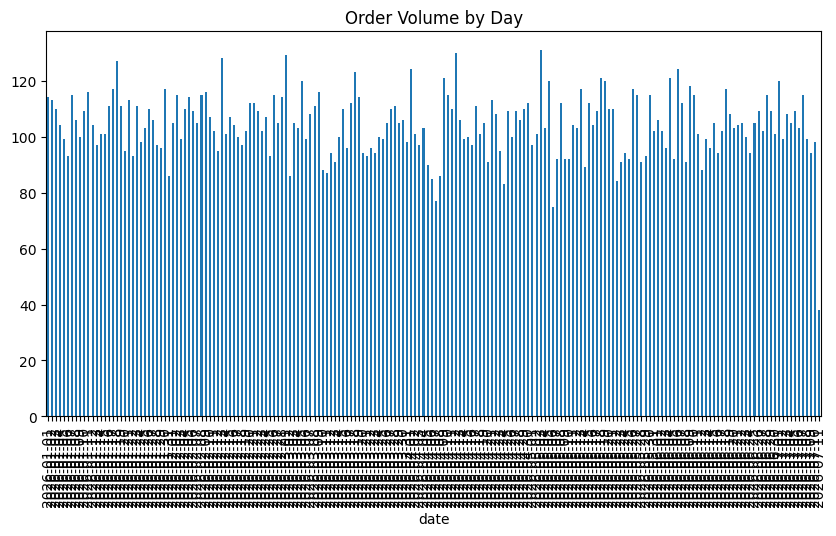

In [ ]:
# -------------------------
# 7. Charts
# -------------------------
# Example: Order volume by day
df_orders1 = pd.DataFrame(orders_day1)
df_orders1['date'] = pd.to_datetime(df_orders1['order_ts']).dt.date
plt.figure(figsize=(10,5))
df_orders1['date'].value_counts().sort_index().plot(kind='bar')
plt.title("Order Volume by Day")
plt.savefig("charts/order_volume_day.png")

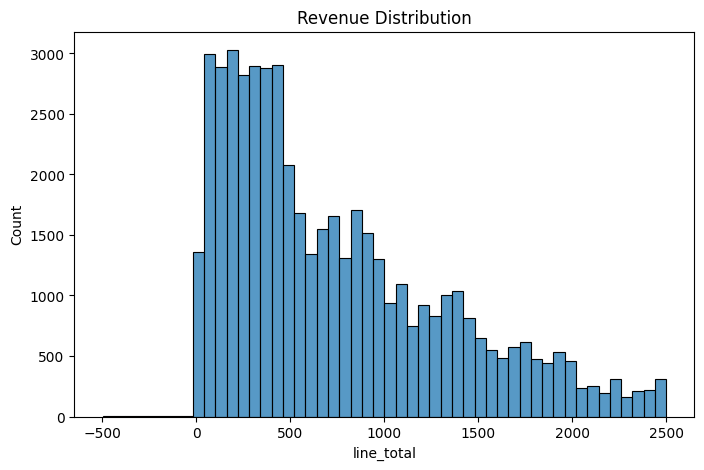

In [ ]:
# Revenue distribution
df_items1 = pd.DataFrame(order_items_day1)
plt.figure(figsize=(8,5))
sns.histplot(df_items1['line_total'], bins=50)
plt.title("Revenue Distribution")
plt.savefig("charts/revenue_distribution.png")

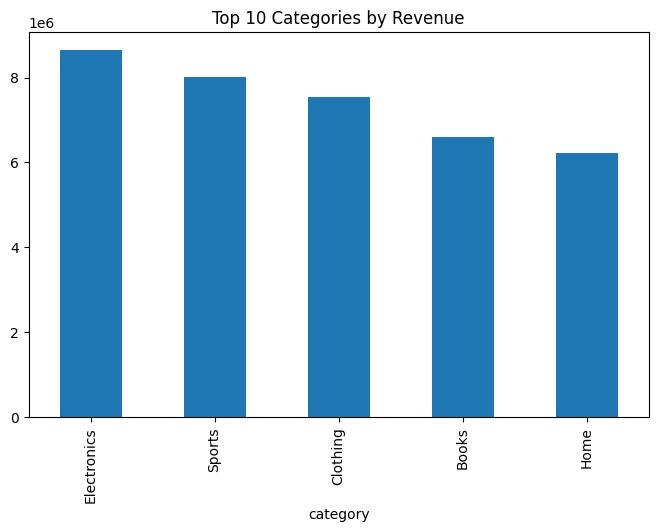

In [ ]:
# Top 10 categories by revenue
df_items1 = pd.DataFrame(order_items_day1)
df_products = pd.DataFrame(products)
merged = df_items1.merge(df_products, on="product_id", how="left")
top10 = merged.groupby("category")['line_total'].sum().nlargest(10)
plt.figure(figsize=(8,5))
top10.plot(kind="bar")
plt.title("Top 10 Categories by Revenue")
plt.savefig("charts/top10_categories.png")

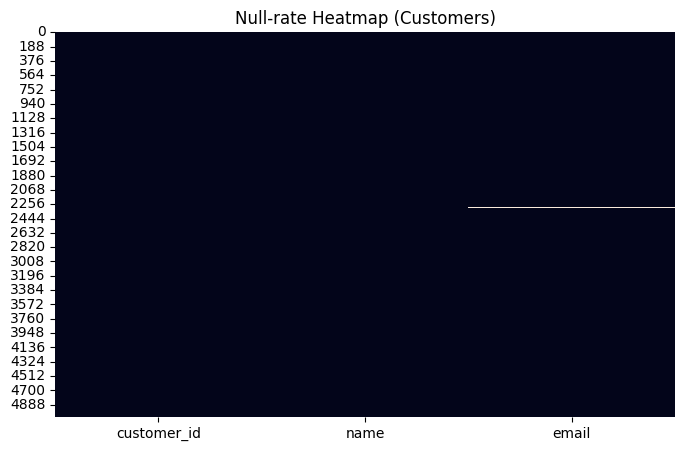

In [ ]:
# Null-rate heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df_customers.isnull(), cbar=False)
plt.title("Null-rate Heatmap (Customers)")
plt.savefig("charts/null_heatmap.png")